# 다변량 시계열 이상 탐지 — EDA
인천대학교 기계학습 기말 프로젝트

## 1. 라이브러리 불러오기

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('모든 라이브러리 정상 로드!')

pandas: 3.0.3
numpy: 2.4.6
모든 라이브러리 정상 로드!


## 2. 데이터 불러오기

In [20]:
train = pd.read_csv('data/train.csv')
val   = pd.read_csv('data/val.csv')
test  = pd.read_csv('data/test_public.csv')

print('train shape:', train.shape)
print('val   shape:', val.shape)
print('test  shape:', test.shape)

train shape: (30000, 11)
val   shape: (15000, 12)
test  shape: (20000, 12)


## 3. 데이터 기본 정보

In [21]:
# train 컬럼 확인
print('train 컬럼:', list(train.columns))
print()
train.head()

train 컬럼: ['t', 'x_3a', 'x_06', 'x_b1', 'x_7e', 'x_92', 'x_29', 'x_d4', 'x_4b', 'x_5c', 'x_f8']



,t,x_3a,x_06,x_b1,x_7e,x_92,x_29,x_d4,x_4b,x_5c,x_f8
0,0,48.597037,1.0,0.140303,24.974895,0.0,6.686982,0.0,0.0,0.972448,22.025125
1,1,46.989782,1.0,0.957211,25.652101,0.0,0.000000,0.0,0.0,0.981402,22.030628
2,2,51.937353,1.0,2.345783,24.948010,0.0,1.102245,0.0,0.0,0.867604,22.053591
3,3,50.081326,1.0,2.877580,24.539312,0.0,0.000000,0.0,0.0,1.005693,22.032875
4,4,49.518314,1.0,4.905106,24.863596,0.0,2.372487,0.0,0.0,0.947125,22.032396


In [22]:
# val 컬럼 확인 (label 컬럼 있음)
print('val 컬럼:', list(val.columns))
print()
val.head()

val 컬럼: ['t', 'x_3a', 'x_06', 'x_b1', 'x_7e', 'x_92', 'x_29', 'x_d4', 'x_4b', 'x_5c', 'x_f8', 'label']



,t,x_3a,x_06,x_b1,x_7e,x_92,x_29,x_d4,x_4b,x_5c,x_f8,label
0,0,49.232378,1.0,0.198076,25.620622,0.0,0.000000,0.248236,0.0,1.028262,22.002688,0
1,1,54.270614,1.0,-0.405667,25.121475,0.0,4.965861,0.318264,0.0,0.995620,21.992688,0
2,2,48.562902,1.0,0.846556,24.394367,0.0,1.129742,0.000000,0.0,0.989380,21.988671,0
3,3,47.893878,1.0,1.915174,24.494083,0.0,0.000000,0.000000,0.0,1.070579,22.004410,0
4,4,49.732776,1.0,3.830160,24.597669,0.0,0.000000,0.000000,0.0,1.055307,22.009156,0


In [23]:
# val 이상치 비율
n_anomaly = val['label'].sum()
n_total   = len(val)
print(f'val 전체: {n_total}')
print(f'이상치:   {n_anomaly} ({n_anomaly/n_total*100:.2f}%)')
print(f'정상:     {n_total - n_anomaly} ({(n_total-n_anomaly)/n_total*100:.2f}%)')

val 전체: 15000
이상치:   2334 (15.56%)
정상:     12666 (84.44%)


In [24]:
# 피처 채널 목록
feature_cols = [c for c in train.columns if c not in ['t', 'label']]
print('피처 채널:', feature_cols)
print('채널 수:', len(feature_cols))

피처 채널: ['x_3a', 'x_06', 'x_b1', 'x_7e', 'x_92', 'x_29', 'x_d4', 'x_4b', 'x_5c', 'x_f8']
채널 수: 10


In [25]:
# 기초 통계
train[feature_cols].describe().round(4)

,x_3a,x_06,x_b1,x_7e,x_92,x_29,x_d4,x_4b,x_5c,x_f8
count,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,10.0456,0.1990,75.2643,60.4916,0.2024,303.3205,11.9518,0.2967,1.1478,22.5068
std,19.9351,0.3993,32.1884,21.6435,0.4018,458.4318,18.2694,0.4568,0.2362,1.1855
min,0.0000,0.0000,-2.9554,22.8686,0.0000,0.0000,0.0000,0.0000,0.8110,20.9124
25%,0.0000,0.0000,50.6637,38.4892,0.0000,0.0000,0.0000,0.0000,0.9810,21.5991
50%,0.0972,0.0000,98.0554,69.2868,0.0000,2.8202,0.1658,0.0000,1.0275,21.9427
75%,0.4605,0.0000,100.0295,79.2673,0.0000,976.4080,37.5302,1.0000,1.4176,23.4641
max,57.4004,1.0000,103.7876,83.9340,1.0000,1100.0418,50.2105,1.0000,1.8519,25.2834


* 이산형 채널: x_06, x_92, x_4b
* 우편향 채널: x_3a, x_29, x_d4 <- 로버스트 스케일러가 적절
* 나머지 채널은 스탠다드 스케일러가 적절

## 4. 채널 분포 분석

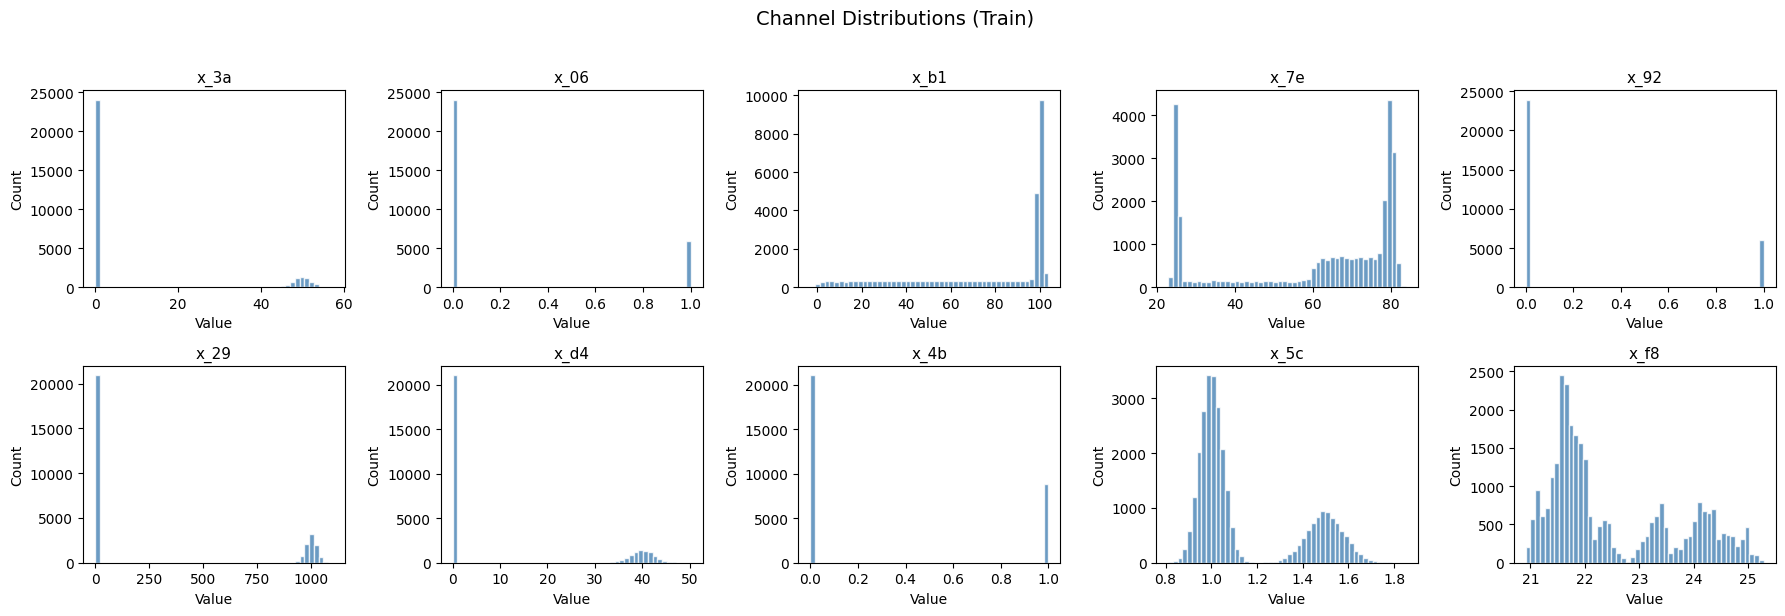

저장 완료: fig1_distribution.png


In [26]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(train[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Channel Distributions (Train)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장 완료: fig1_distribution.png')

## 5. 시계열 패턴 분석

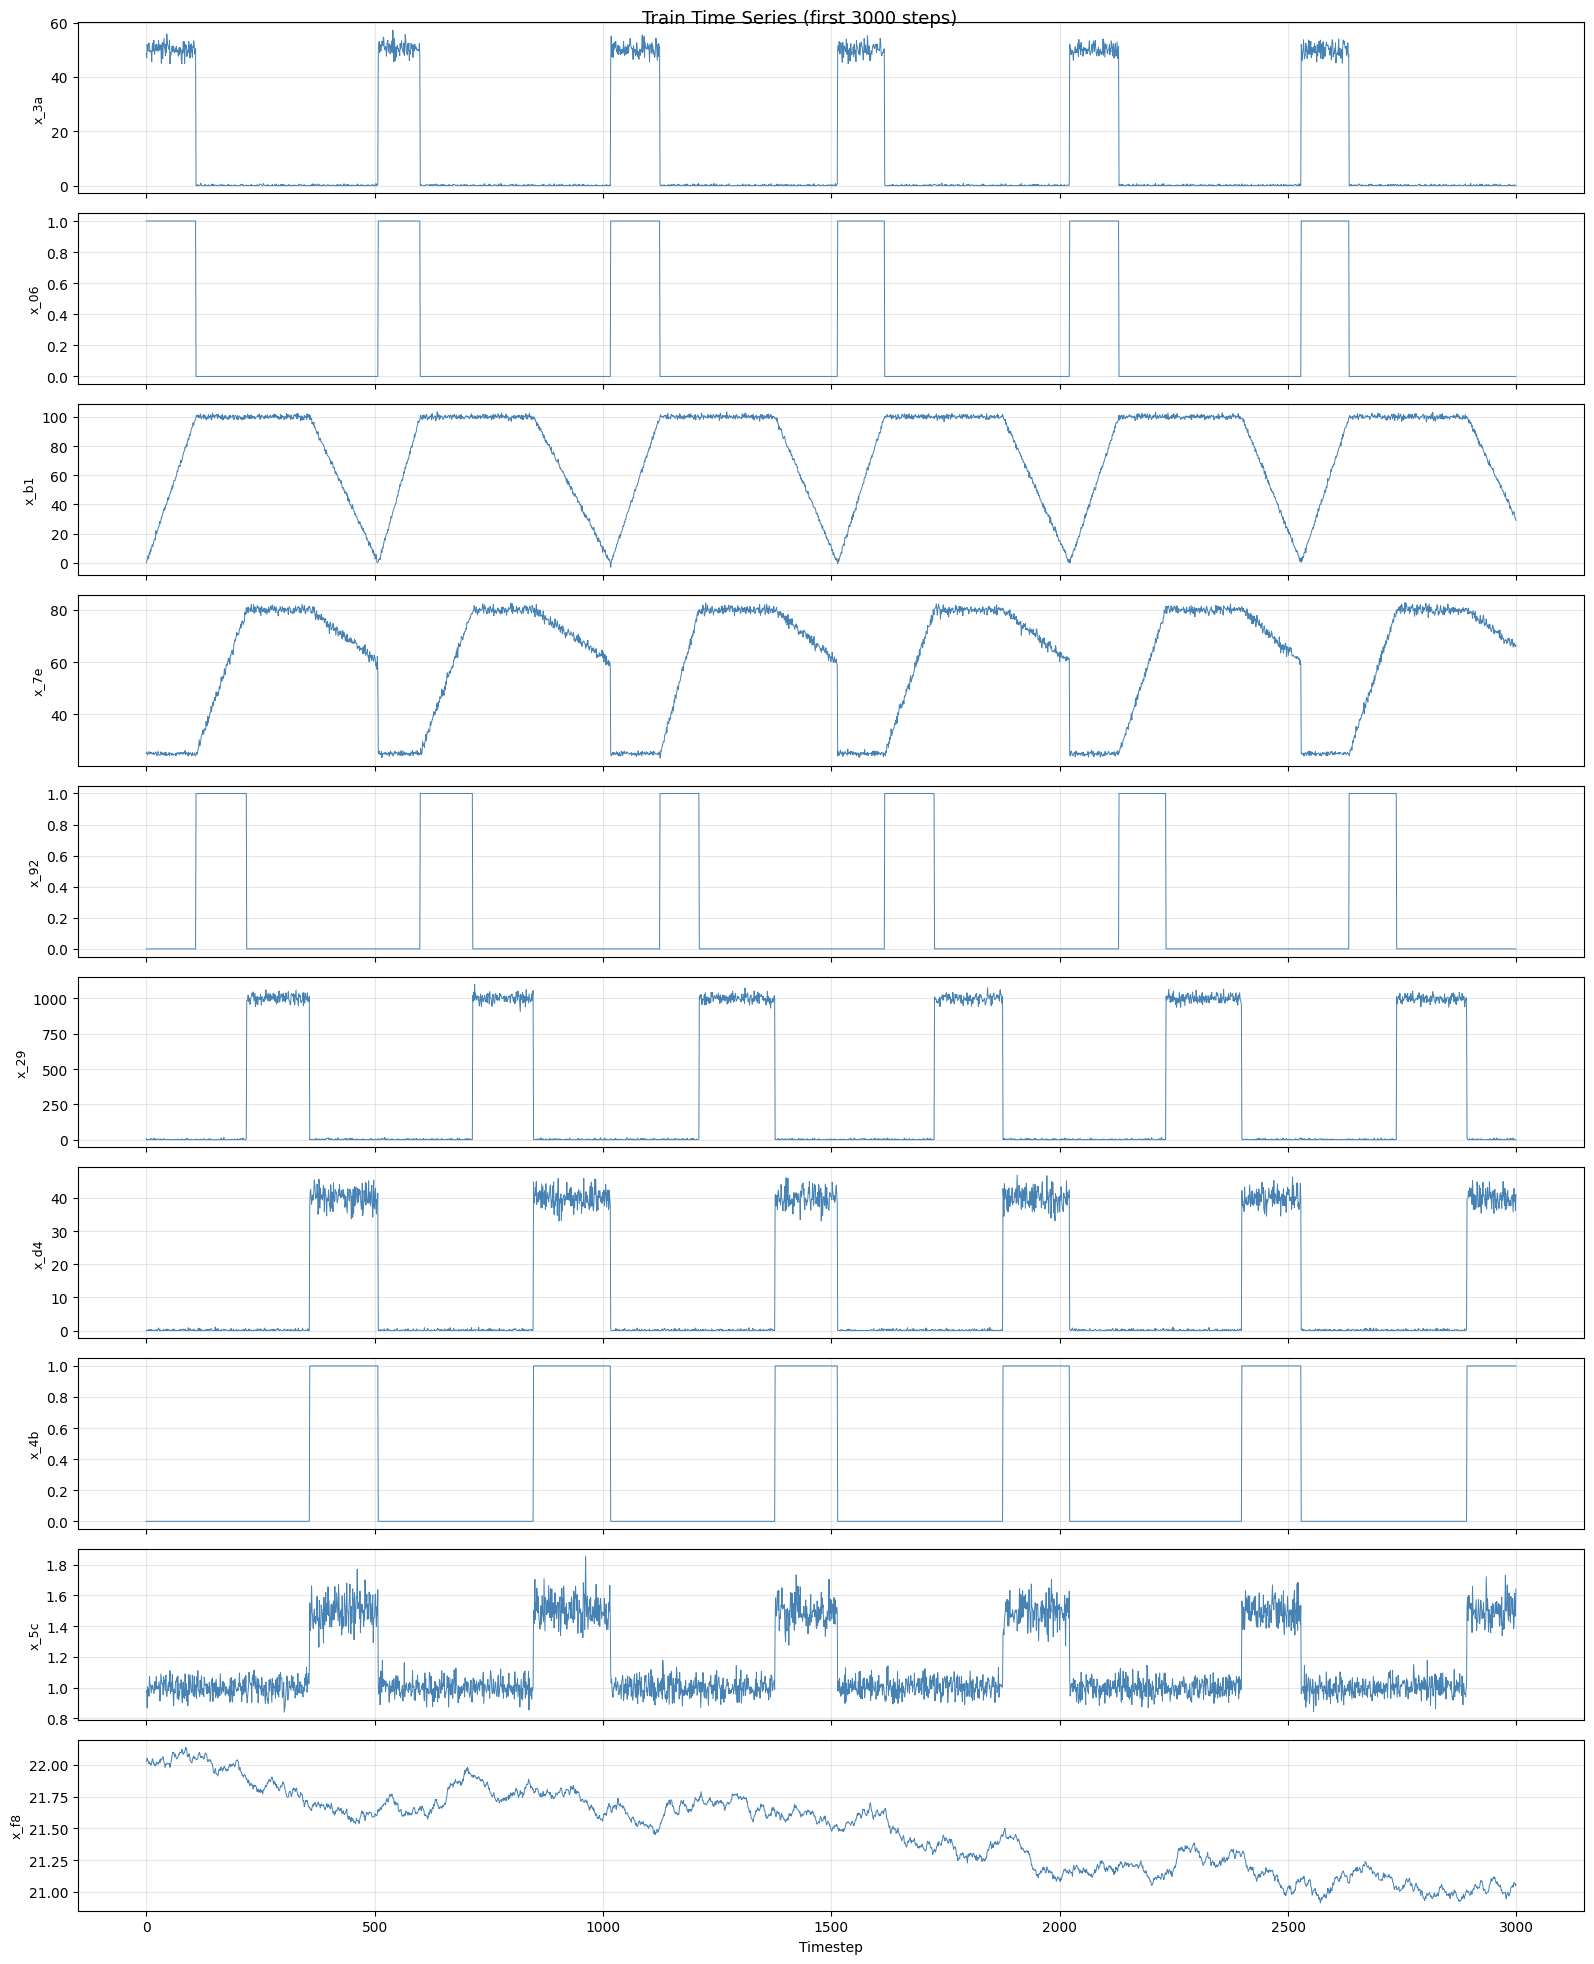

저장 완료: fig2_timeseries_train.png


In [27]:
# train 시계열 — 앞 3000 타임스텝
fig, axes = plt.subplots(10, 1, figsize=(16, 20), sharex=True)

plot_n = 3000
for i, col in enumerate(feature_cols):
    axes[i].plot(train[col].iloc[:plot_n], color='steelblue', linewidth=0.7)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Timestep')
plt.suptitle(f'Train Time Series (first {plot_n} steps)', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_timeseries_train.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장 완료: fig2_timeseries_train.png')

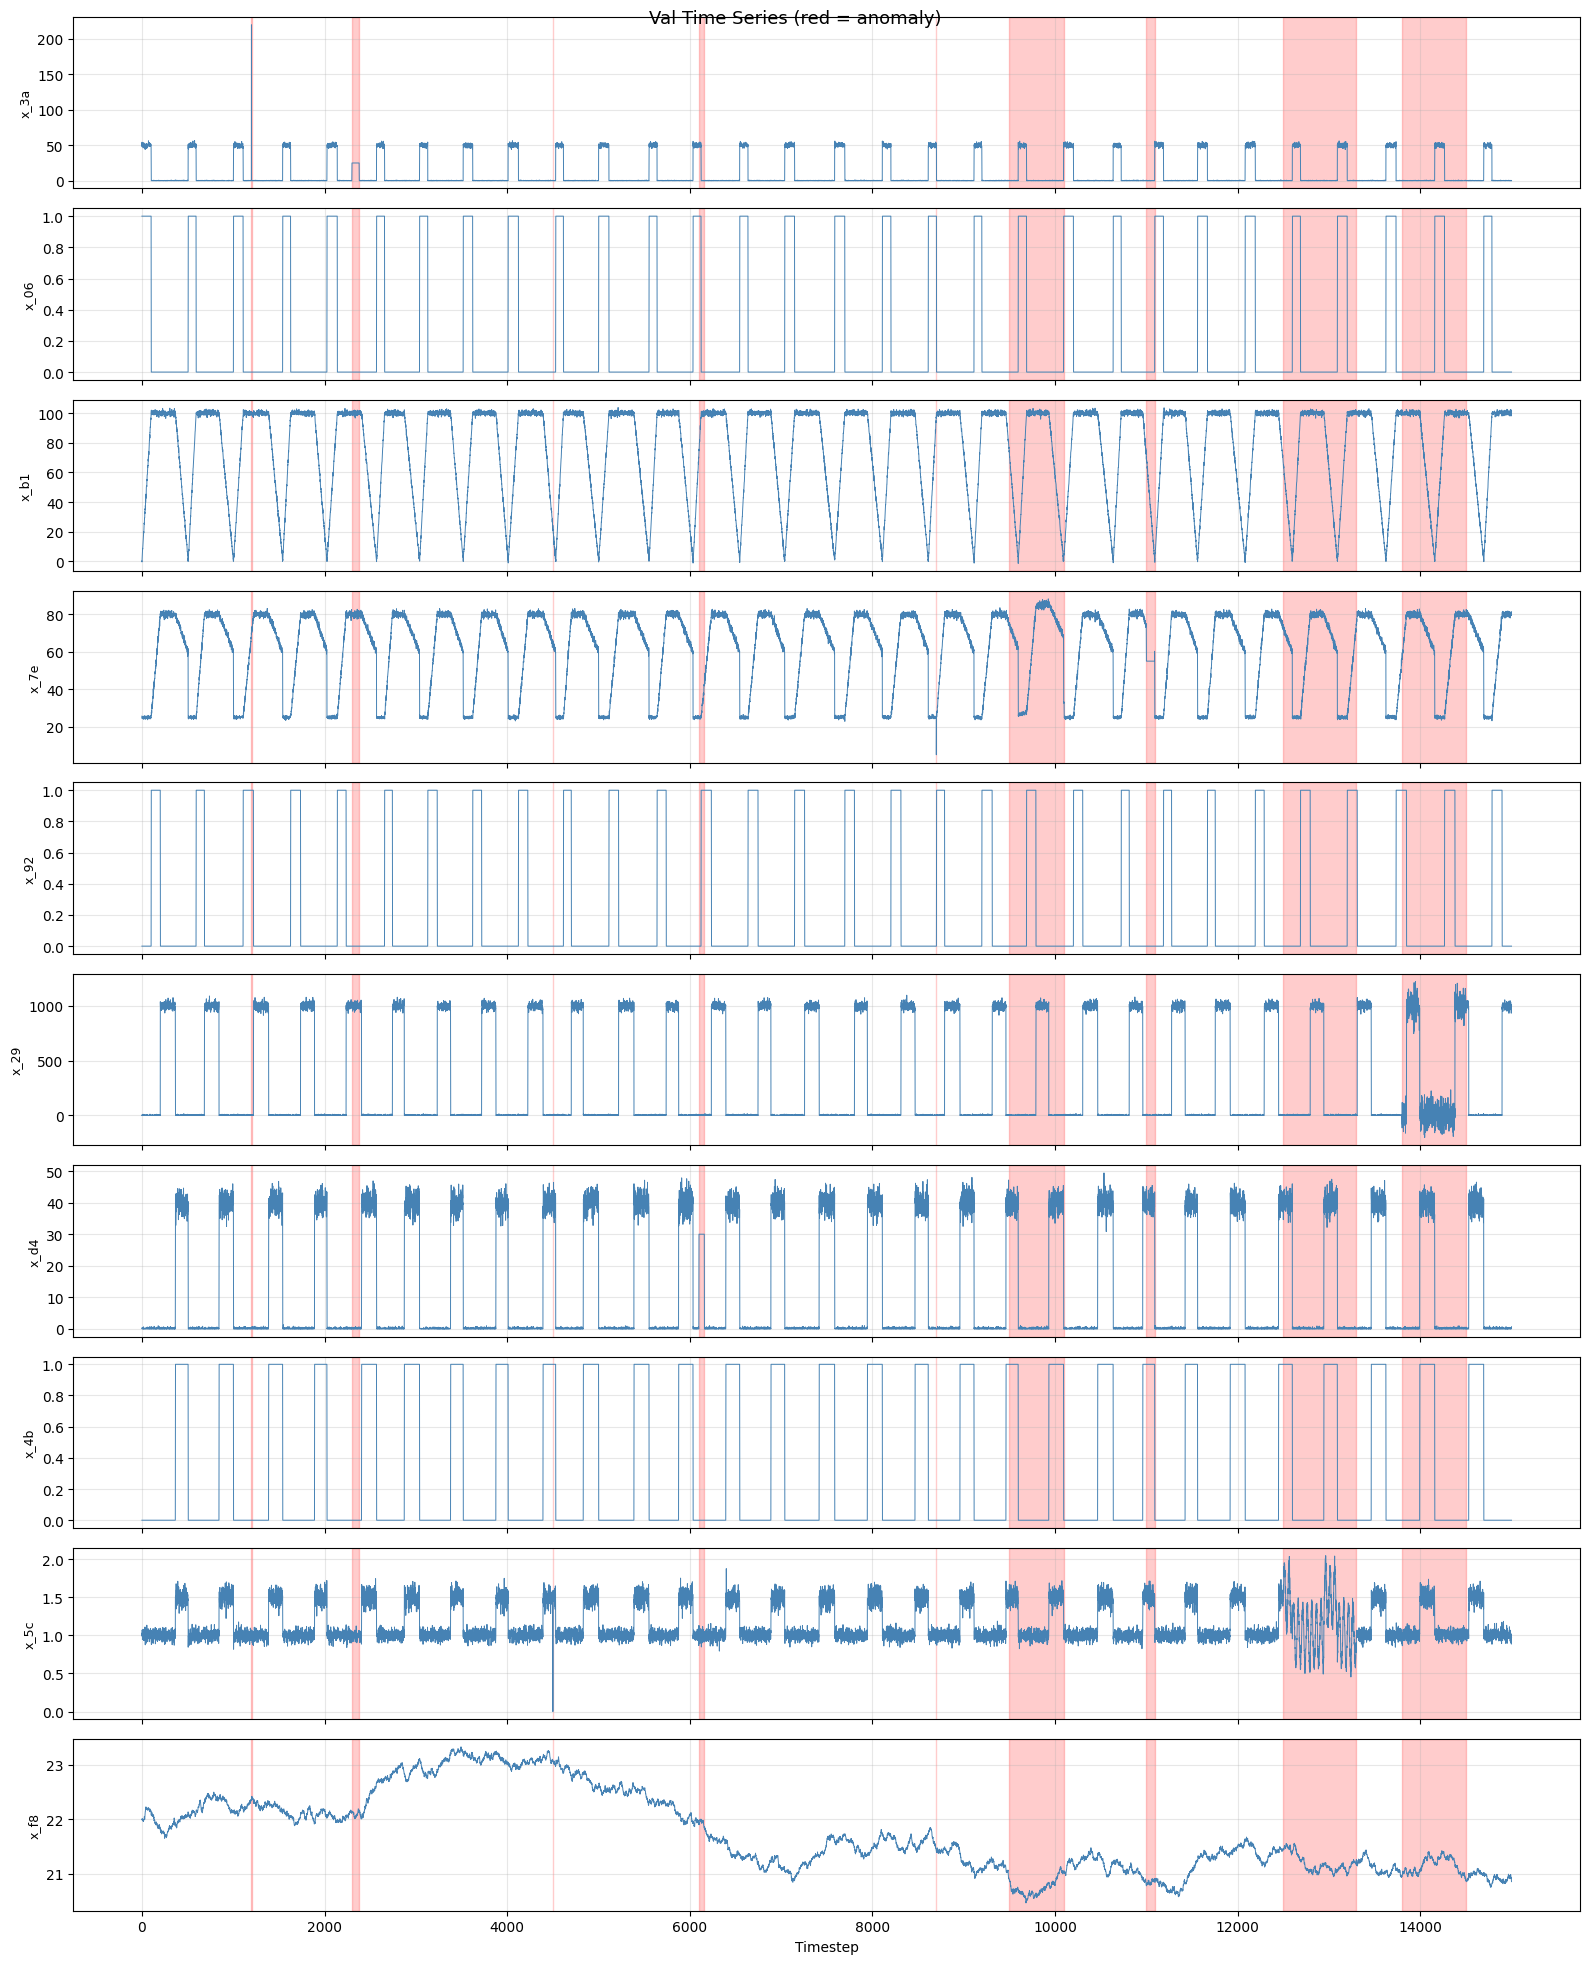

저장 완료: fig3_timeseries_val.png


In [28]:
# val 시계열 — 이상 구간 빨간색으로 표시
fig, axes = plt.subplots(10, 1, figsize=(16, 20), sharex=True)

val_features = [c for c in feature_cols if c in val.columns]

for i, col in enumerate(val_features):
    axes[i].plot(val[col].values, color='steelblue', linewidth=0.7)
    
    # 이상 구간 빨간 배경
    in_anomaly = False
    start = 0
    for t, label in enumerate(val['label']):
        if label == 1 and not in_anomaly:
            start = t
            in_anomaly = True
        elif label == 0 and in_anomaly:
            axes[i].axvspan(start, t, color='red', alpha=0.2)
            in_anomaly = False
    if in_anomaly:
        axes[i].axvspan(start, len(val), color='red', alpha=0.2)
    
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Timestep')
plt.suptitle('Val Time Series (red = anomaly)', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_timeseries_val.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장 완료: fig3_timeseries_val.png')

In [29]:
# 이상 구간 자동 추출
intervals = []
in_anomaly = False
start = 0
for t, label in enumerate(val['label']):
    if label == 1 and not in_anomaly:
        start = t
        in_anomaly = True
    elif label == 0 and in_anomaly:
        intervals.append((start, t))
        in_anomaly = False
if in_anomaly:
    intervals.append((start, len(val)))

print(f'이상 구간 수: {len(intervals)}')
for i, (s, e) in enumerate(intervals):
    print(f'  구간 {i+1}: t={s} ~ t={e} (길이 {e-s})')

이상 구간 수: 9
  구간 1: t=1200 ~ t=1201 (길이 1)
  구간 2: t=2300 ~ t=2380 (길이 80)
  구간 3: t=4500 ~ t=4502 (길이 2)
  구간 4: t=6100 ~ t=6160 (길이 60)
  구간 5: t=8700 ~ t=8701 (길이 1)
  구간 6: t=9500 ~ t=10100 (길이 600)
  구간 7: t=11000 ~ t=11090 (길이 90)
  구간 8: t=12500 ~ t=13300 (길이 800)
  구간 9: t=13800 ~ t=14500 (길이 700)


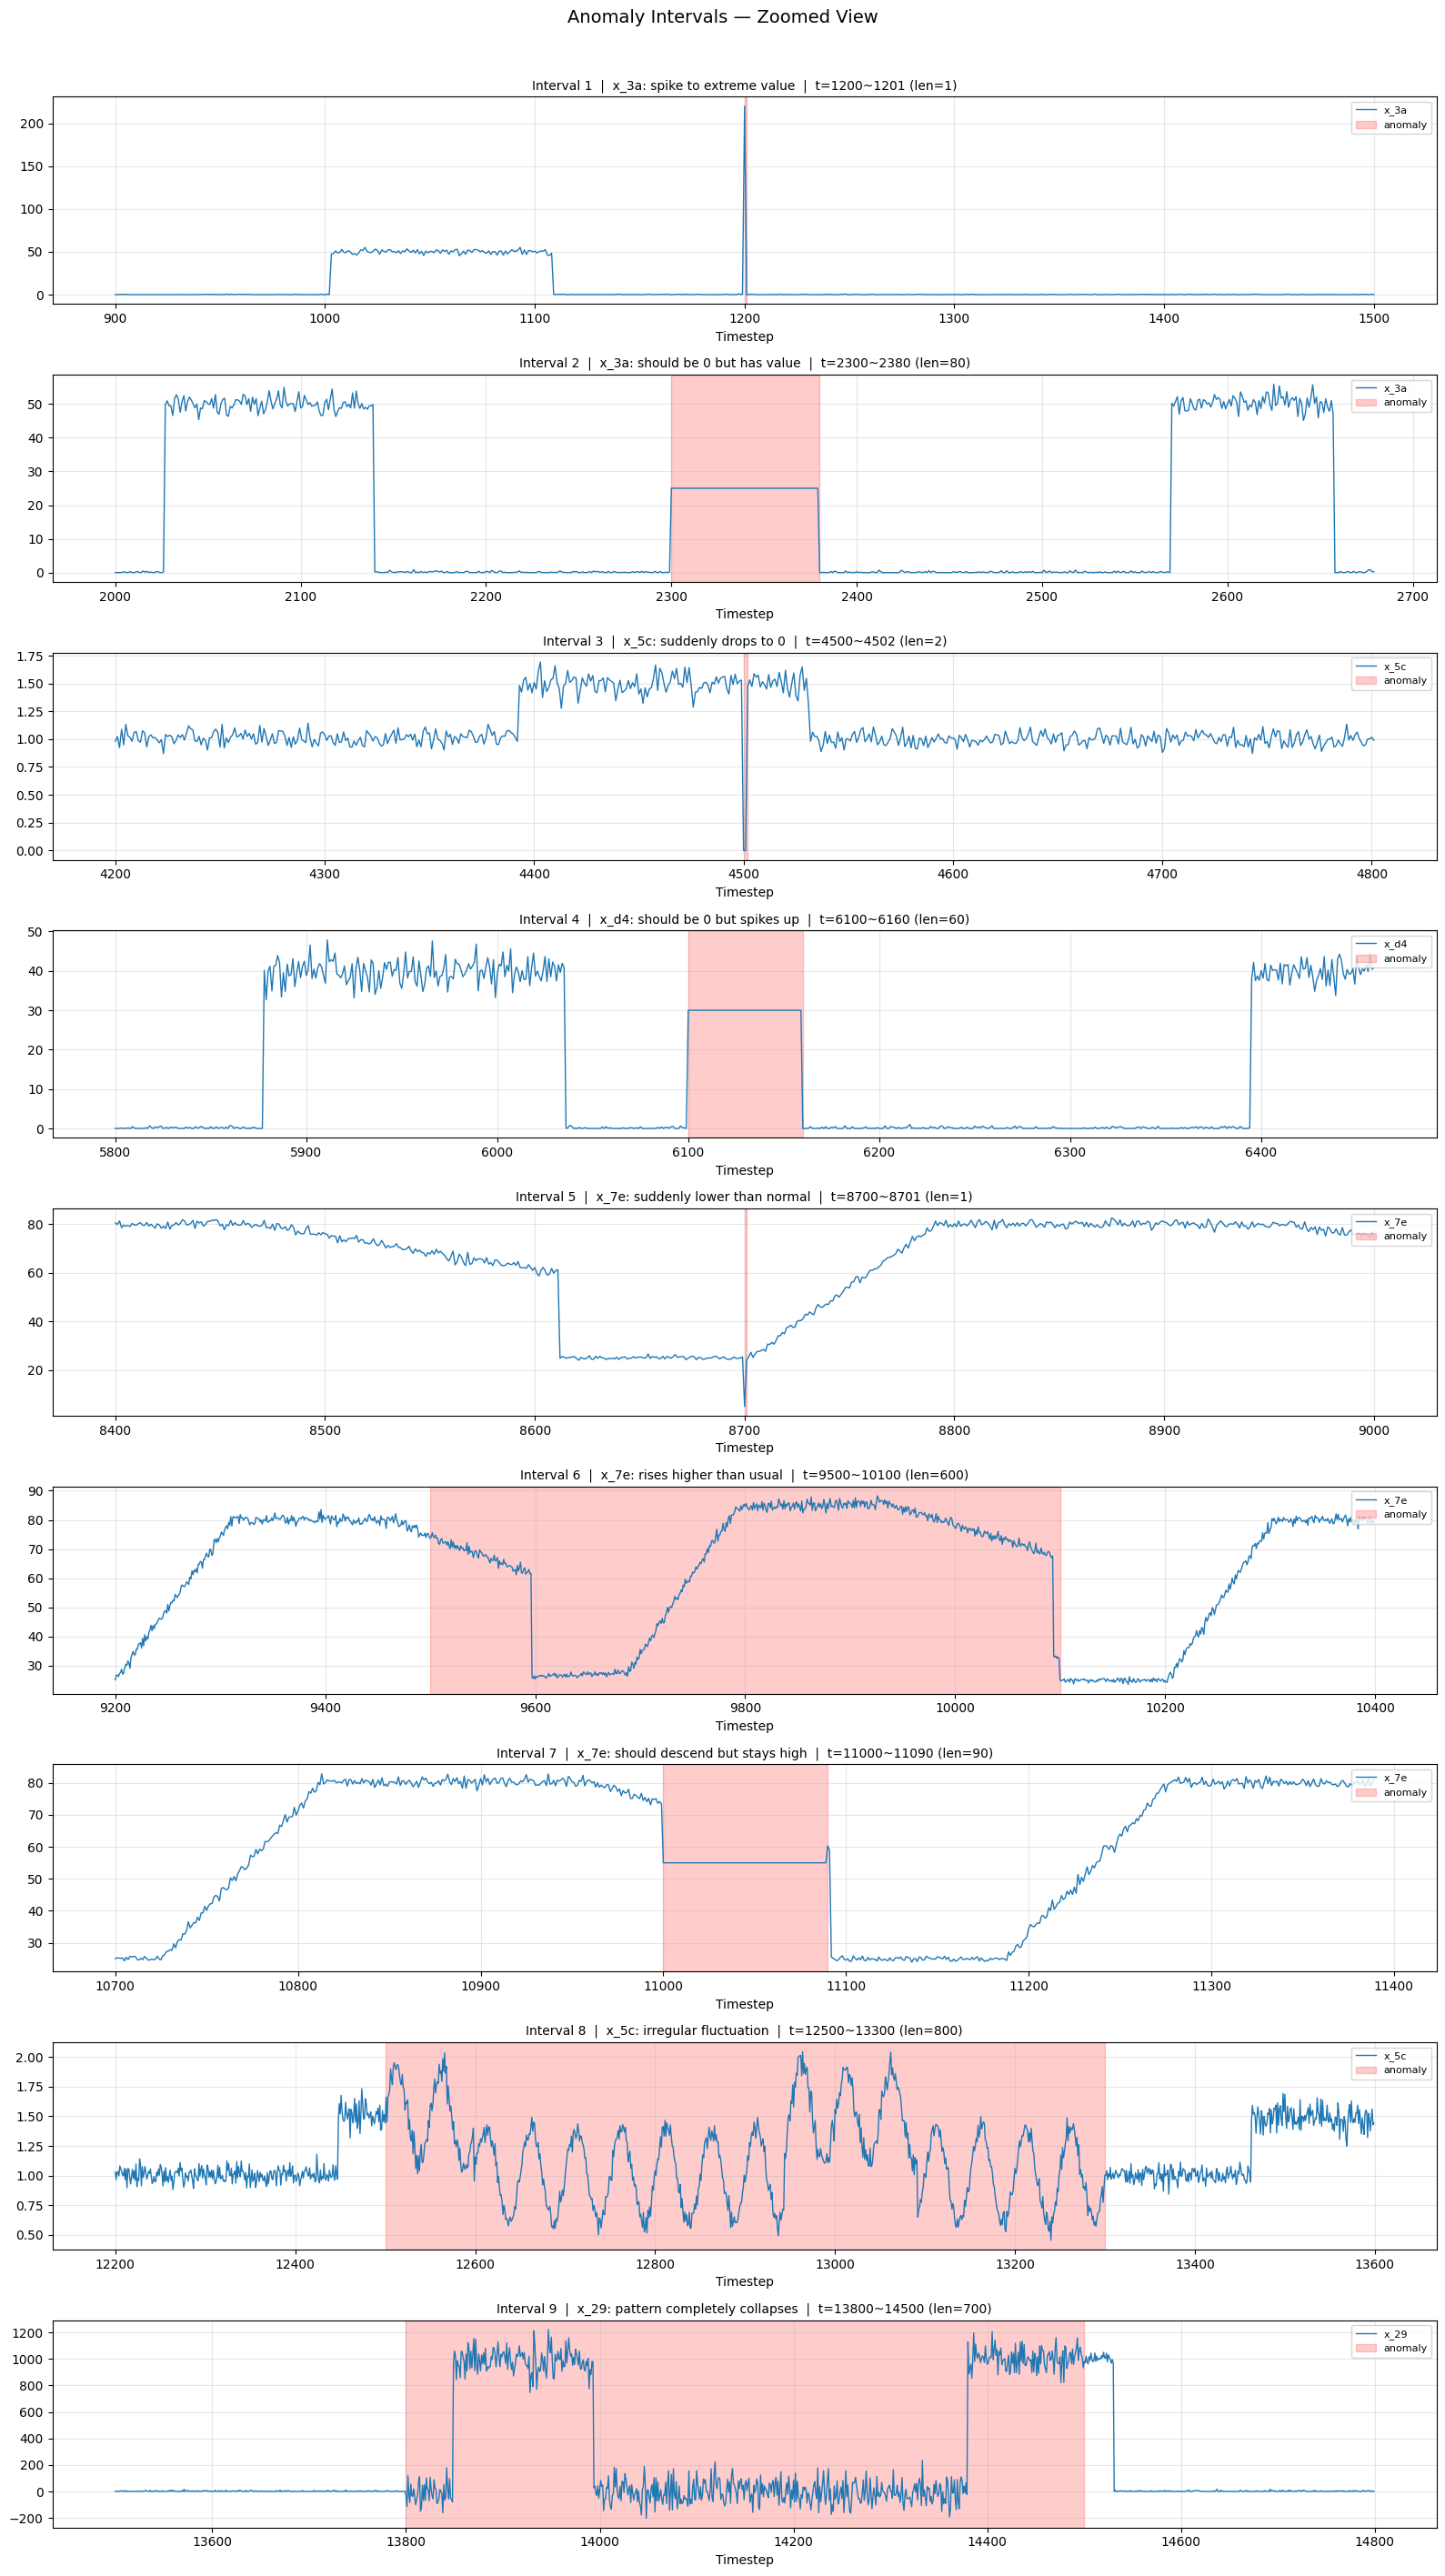

In [31]:
# 구간별 핵심 채널 (Hannah 분석 기반)
interval_channels = {
    1: ['x_3a'],
    2: ['x_3a'],
    3: ['x_5c'],
    4: ['x_d4'],
    5: ['x_7e'],
    6: ['x_7e'],
    7: ['x_7e'],
    8: ['x_5c'],
    9: ['x_29'],
}

interval_notes = {
    1: 'x_3a: spike to extreme value',
    2: 'x_3a: should be 0 but has value',
    3: 'x_5c: suddenly drops to 0',
    4: 'x_d4: should be 0 but spikes up',
    5: 'x_7e: suddenly lower than normal',
    6: 'x_7e: rises higher than usual',
    7: 'x_7e: should descend but stays high',
    8: 'x_5c: irregular fluctuation',
    9: 'x_29: pattern completely collapses',
}

PADDING = 300

fig, axes = plt.subplots(9, 1, figsize=(16, 28))

for idx, (s, e) in enumerate(intervals):
    n = idx + 1
    channels = interval_channels[n]
    note = interval_notes[n]
    
    view_start = max(0, s - PADDING)
    view_end   = min(len(val), e + PADDING)
    
    ax = axes[idx]
    for col in channels:
        ax.plot(range(view_start, view_end),
                val[col].iloc[view_start:view_end].values,
                label=col, linewidth=1.0)
    
    ax.axvspan(s, e, color='red', alpha=0.2, label='anomaly')
    ax.set_title(f'Interval {n}  |  {note}  |  t={s}~{e} (len={e-s})', fontsize=10)
    ax.set_xlabel('Timestep')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Anomaly Intervals — Zoomed View', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_zoom_intervals.png', dpi=100, bbox_inches='tight')
plt.show()

# 이상 구간 분류 및 탐지 전략

## 이상치 유형 정의

| 유형 | 설명 |
|------|------|
| Point Anomaly | 단일 스텝에서 값 자체가 비정상적인 경우 |
| Contextual Anomaly | 값 자체는 정상 범위지만 맥락상 비정상인 경우 |
| Collective Anomaly | 개별 포인트는 정상이지만 연속된 구간 전체가 비정상인 경우 |

---

## 구간별 분류

### 구간 1 — x_3a 극단값 급등
- **유형**: Point Anomaly
- **현상**: x_3a가 평소 최대 50~60인데 순간적으로 180 이상으로 급등
- **탐지 전략**: 윈도우 내 최댓값(max) 피처 → 평소 범위를 크게 벗어나면 이상

---

### 구간 2 — x_3a가 0이어야 하는데 값이 있음
- **유형**: Contextual Anomaly
- **현상**: x_3a는 사이클상 0으로 내려가야 하는 구간인데 0이 아닌 값이 유지됨. 값 자체는 크지 않지만 맥락상 비정상
- **탐지 전략**: 사이클 위상(phase) 파악 후, 해당 위상에서의 기대값과 실제값 차이를 피처로 사용

---

### 구간 3 — x_5c가 갑자기 0으로 떨어짐
- **유형**: Point Anomaly
- **현상**: x_5c는 평소 0.8~1.8 사이를 유지하는데 순간적으로 0 근처로 뚝 떨어짐
- **탐지 전략**: 윈도우 내 최솟값(min) 피처 → 평소 하한선 아래로 내려가면 이상

---

### 구간 4 — x_d4가 0이어야 하는데 위로 튐
- **유형**: Contextual Anomaly
- **현상**: x_d4는 사이클상 0에 수렴해야 하는 구간인데 갑자기 위로 튀어오름. 값 자체는 크지 않아도 맥락상 비정상
- **탐지 전략**: 구간 2와 동일하게 사이클 위상 기반 기대값 비교

---

### 구간 5 — x_7e가 갑자기 낮아짐
- **유형**: Contextual Anomaly
- **현상**: x_7e는 올라가야 하는 구간인데 값이 낮게 유지됨. 값이 낮은 것 자체는 정상이지만 이 시점에 낮은 건 비정상
- **탐지 전략**: 이전 윈도우 대비 급격한 하락(기울기) 피처 → 차분(diff) 활용

---

### 구간 6 — x_7e가 평소보다 더 높이 올라감
- **유형**: Contextual Anomaly
- **현상**: x_7e가 올라가는 건 정상이지만 평소 최고점(~82)을 넘어서 더 높이 올라감
- **탐지 전략**: 윈도우 내 최댓값(max) 피처 → 사이클 최고점을 초과하면 이상

---

### 구간 7 — x_7e가 내려가야 하는데 안 내려감
- **유형**: Collective Anomaly
- **현상**: 개별 값은 정상 범위(60~80)이지만, 여러 스텝에 걸쳐 계속 높게 유지됨. 내려가는 패턴이 지속적으로 깨짐
- **탐지 전략**: 윈도우 내 평균(mean)이 비정상적으로 높음 → 통계 피처(mean, std) 활용

---

### 구간 8 — x_5c 불규칙하게 흔들림
- **유형**: Collective Anomaly
- **현상**: 개별 값은 0.8~1.8 범위 내이지만 연속된 구간 동안 진동 폭이 평소보다 매우 커짐
- **탐지 전략**: 윈도우 내 표준편차(std) 피처 → 평소보다 std가 크게 높아지면 이상

---

### 구간 9 — x_29 패턴 완전히 붕괴
- **유형**: Collective Anomaly
- **현상**: x_29는 평소 0 아니면 1000을 깔끔하게 오가는데, 이 구간에서는 0~1000 사이를 불규칙하게 계속 진동함
- **탐지 전략**: 윈도우 내 표준편차(std) 또는 0/1000이 아닌 중간값 비율 피처 → 패턴 붕괴 감지

---

## 유형별 탐지 전략 요약

| 유형 | 해당 구간 | 핵심 피처 |
|------|----------|---------|
| Point Anomaly | 1, 3 | 윈도우 내 max, min |
| Contextual Anomaly | 2, 4, 5, 6 | 사이클 위상 기반 기대값 차이, diff(기울기) |
| Collective Anomaly | 7, 8, 9 | 윈도우 내 mean, std |

→ 세 유형을 모두 잡으려면 **max, min, mean, std, diff**를 피처로 함께 사용하는 것이 효과적

## 6. 채널 간 상관관계

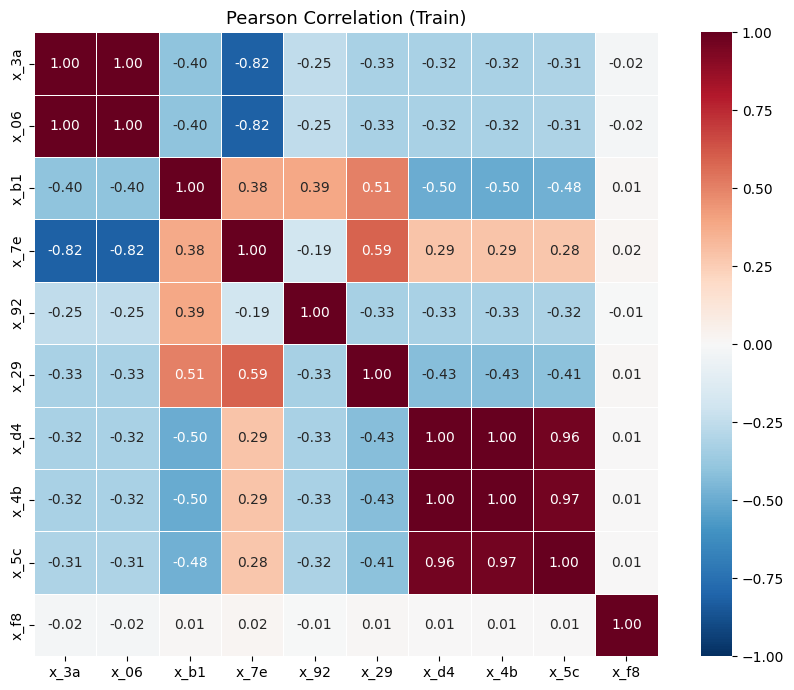

저장 완료: fig4_correlation.png

|상관계수| > 0.5인 채널 쌍:
  x_3a <-> x_06 : 0.999
  x_3a <-> x_7e : -0.817
  x_06 <-> x_7e : -0.817
  x_b1 <-> x_29 : 0.505
  x_b1 <-> x_4b : -0.500
  x_7e <-> x_29 : 0.593
  x_d4 <-> x_4b : 0.997
  x_d4 <-> x_5c : 0.963
  x_4b <-> x_5c : 0.966


In [14]:
corr = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Pearson Correlation (Train)', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장 완료: fig4_correlation.png')

# 강한 상관관계 쌍 출력
print('\n|상관계수| > 0.5인 채널 쌍:')
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.5:
            print(f'  {feature_cols[i]} <-> {feature_cols[j]} : {c:.3f}')

## 7. 강한 상관관계 쌍 산점도

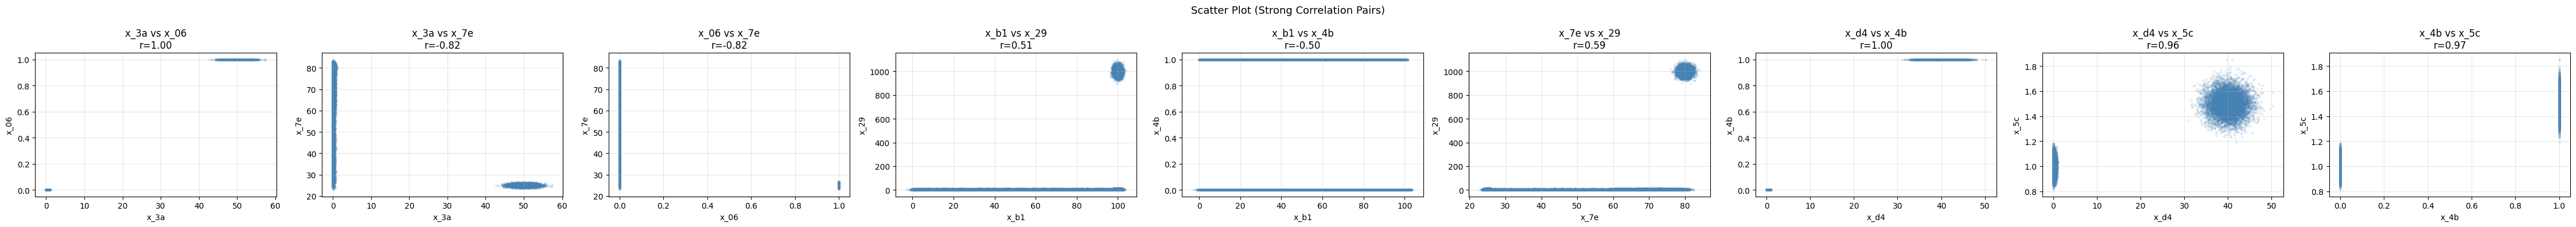

저장 완료: fig5_scatter.png


In [15]:
# 상관관계 0.5 이상인 쌍 자동 추출
strong_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.5:
            strong_pairs.append((feature_cols[i], feature_cols[j], c))

if strong_pairs:
    n = len(strong_pairs)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, (col_a, col_b, c) in zip(axes, strong_pairs):
        ax.scatter(train[col_a], train[col_b], alpha=0.1, s=5, color='steelblue')
        ax.set_xlabel(col_a)
        ax.set_ylabel(col_b)
        ax.set_title(f'{col_a} vs {col_b}\nr={c:.2f}')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Scatter Plot (Strong Correlation Pairs)', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig5_scatter.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('저장 완료: fig5_scatter.png')
else:
    print('강한 상관관계 쌍이 없습니다.')

이상 탐지 피처로 쓸 수 있는 것들:

* x_3a > 0인데 x_06 != 1 → 관계 붕괴 → 이상 신호
* x_d4 > 0인데 x_4b != 1 → 관계 붕괴 → 이상 신호
* x_d4 상태인데 x_5c가 기대 범위 밖 → 이상 신호

## 8. 이상 구간 분석

In [16]:
# 이상 구간 목록 추출
intervals = []
in_anomaly = False
start = 0
for t, label in enumerate(val['label']):
    if label == 1 and not in_anomaly:
        start = t
        in_anomaly = True
    elif label == 0 and in_anomaly:
        intervals.append((start, t, t - start))
        in_anomaly = False
if in_anomaly:
    intervals.append((start, len(val), len(val) - start))

print(f'이상 구간 수: {len(intervals)}')
print(f'{'구간':>4}  {'시작':>6}  {'끝':>6}  {'길이':>6}')
print('-' * 30)
for i, (s, e, l) in enumerate(intervals):
    print(f'{i+1:>4}  {s:>6}  {e:>6}  {l:>6}')

lengths = [l for _, _, l in intervals]
print(f'\n평균 길이: {np.mean(lengths):.1f}')
print(f'최소 길이: {min(lengths)}')
print(f'최대 길이: {max(lengths)}')

이상 구간 수: 9
  구간      시작       끝      길이
------------------------------
   1    1200    1201       1
   2    2300    2380      80
   3    4500    4502       2
   4    6100    6160      60
   5    8700    8701       1
   6    9500   10100     600
   7   11000   11090      90
   8   12500   13300     800
   9   13800   14500     700

평균 길이: 259.3
최소 길이: 1
최대 길이: 800


## 9. 정상 vs 이상 채널 평균 비교

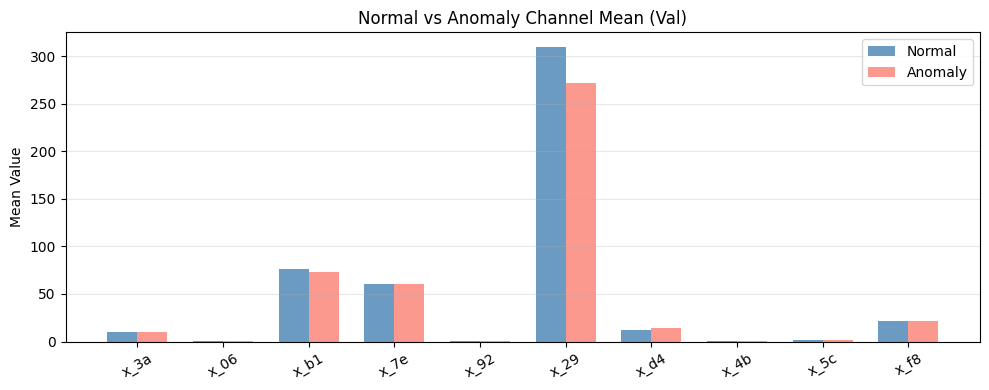

저장 완료: fig6_normal_vs_anomaly.png

차이가 큰 채널 순서:
x_29    37.7729
x_b1     2.8582
x_d4     2.2175
x_f8     0.7535
x_7e     0.1500
x_3a     0.1415
x_4b     0.0359
x_92     0.0167
x_06     0.0164
x_5c     0.0163
dtype: float64


In [17]:
normal_mean  = val[val['label']==0][val_features].mean()
anomaly_mean = val[val['label']==1][val_features].mean()

diff = (anomaly_mean - normal_mean).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(val_features))
w = 0.35
ax.bar(x - w/2, normal_mean[val_features],  w, label='Normal',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, anomaly_mean[val_features], w, label='Anomaly', color='salmon',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(val_features, rotation=30)
ax.set_ylabel('Mean Value')
ax.set_title('Normal vs Anomaly Channel Mean (Val)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig6_normal_vs_anomaly.png', dpi=100, bbox_inches='tight')
plt.show()
print('저장 완료: fig6_normal_vs_anomaly.png')

print('\n차이가 큰 채널 순서:')
print(diff.round(4))

## EDA 종합 분석 및 개선 계획

---

### 1. 채널 유형 분류

| 유형 | 채널 |
|------|------|
| 연속형 (사이클) | x_b1, x_7e, x_29 |
| 이산형 (0/1) | x_06, x_92, x_4b |
| 우편향 (극단값) | x_3a, x_29, x_d4 |
| Drift | x_f8 |

---

### 2. 구간별 이상 유형 분류

| 구간 | 채널 | 유형 |
|------|------|------|
| 1 | x_3a | Point — 극단값 급등 |
| 2 | x_3a | Contextual — 0이어야 하는데 값 있음 |
| 3 | x_5c | Point — 갑자기 0으로 떨어짐 |
| 4 | x_d4 | Contextual — 0이어야 하는데 위로 튐 |
| 5 | x_7e | Contextual — 올라가야 하는데 낮음 |
| 6 | x_7e | Contextual — 평소보다 더 높이 올라감 |
| 7 | x_7e | Collective — 내려가야 하는데 안 내려감 |
| 8 | x_5c | Collective — 불규칙하게 흔들림 |
| 9 | x_29 | Collective — 패턴 완전히 붕괴 |

---

### 3. 강한 상관관계 쌍

| 쌍 | 상관계수 | 관계 |
|----|---------|------|
| x_3a ↔ x_06 | 1.00 | x_3a > 0이면 x_06 = 1 |
| x_d4 ↔ x_4b | 1.00 | x_d4 > 0이면 x_4b = 1 |
| x_d4 ↔ x_5c | 0.96 | x_d4 상태에 따라 x_5c 범위 달라짐 |
| x_4b ↔ x_5c | 0.97 | 동일 |
| x_3a ↔ x_7e | -0.82 | 반대로 움직임 |

---

### 4. 전처리 계획

```
원본 데이터 (timesteps × 10 channels)
↓
Sliding Window
  - window_size 후보: 100, 200, 400 (사이클 주기 ~300 고려)
  - step: 1 (촘촘하게) 또는 window_size//2 (겹치게)
↓
Feature Extraction (window 하나 → 고정 벡터)
  - mean, std, min, max, range, median  ← 교수님 제시
  - diff (현재값 - 이전값의 통계)        ← Contextual Anomaly 대응
  - 채널 간 관계 피처 (x_3a - x_06 등)  ← 관계 붕괴 대응
↓
Feature Selection (선택사항)
  - 전략 A: 전체 피처 그대로 사용 → Isolation Forest에 적합
  - 전략 B: binary 채널 (x_06, x_92, x_4b) 제거 → 노이즈 감소
↓
StandardScaler
  - train 데이터로만 fit()
  - val, test는 transform()만 적용 (data leakage 방지)
↓
모델 입력 벡터 완성
```

---

### 5. 피처별 잡을 수 있는 이상 유형

| 피처 | 잡는 이상 |
|------|---------|
| max | Point — x_3a 극단값 (구간 1) |
| min | Point — x_5c 급락 (구간 3) |
| std | Collective — x_5c, x_29 불규칙 (구간 8, 9) |
| mean | Collective — x_7e 평균 이탈 (구간 7) |
| diff | Contextual — x_7e 방향 이상 (구간 5, 6, 7) |
| 관계 피처 (x_3a - x_06) | Contextual — 채널 간 관계 붕괴 (구간 2, 4) |

---

### 6. 다음 단계 (2단계: 단순 모델)

- baseline starter.py의 window_size=50 → 100/200/400으로 변경 실험
- flatten 대신 통계 피처 추출로 교체
- Isolation Forest로 먼저 성능 확인 (AUROC, AUPR)
- 목표: AUPR 0.22 (baseline) → 0.4 이상You said: 4번 전처리 계획만 좀 다시 써줘4번 전처리 계획만 좀 다시 써줘Claude responded: 원본 데이터 (timesteps × 10 channels)markdown### 4. 전처리 계획

```
원본 데이터 (timesteps × 10 channels)
↓
Sliding Window
  - window_size 후보: 100, 200, 400 (사이클 주기 ~300 고려)
  - step: 1 (촘촘하게) 또는 window_size//2 (겹치게)
↓
Feature Extraction (window 하나 → 고정 벡터)
  - mean, std, min, max, range, median  ← 교수님 제시
  - diff (현재값 - 이전값의 통계)        ← Contextual Anomaly 대응
  - 채널 간 관계 피처 (x_3a - x_06 등)  ← 관계 붕괴 대응
↓
Feature Selection (선택사항)
  - 전략 A: 전체 피처 그대로 사용 → Isolation Forest에 적합
  - 전략 B: binary 채널 (x_06, x_92, x_4b) 제거 → 노이즈 감소
↓
StandardScaler
  - train 데이터로만 fit()
  - val, test는 transform()만 적용 (data leakage 방지)
↓
모델 입력 벡터 완성
```